## **⚙️ Imports & configuration**


**Objectif :**

Initialiser l’environnement de travail pour l’apprentissage profond et configurer les paramètres globaux du projet.

**Description :**

Cette cellule importe toutes les bibliothèques nécessaires au projet :

*  NumPy, Matplotlib, Seaborn pour la manipulation des données et la visualisation.

*  TensorFlow / Keras pour la construction et l’entraînement des réseaux de neurones convolutionnels (CNN).

*  Modèles pré-entraînés (DenseNet, ResNet, VGG) pour le transfer learning.

*  Scikit-learn pour l’évaluation (matrice de confusion, rapport de classification).

L’option Mixed Precision (mixed_float16) est activée afin d’accélérer l’entraînement et réduire la consommation mémoire sur GPU.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121, ResNet50
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from sklearn.metrics import classification_report, confusion_matrix

# Enable mixed precision for speed
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

## **📂 Chemin d'accès au dataset**

**Objectif :**

Accéder au dataset stocké sur Google Drive et définir les paramètres globaux.

**Description :**

*  Le Google Drive est monté afin d’accéder aux images du dataset.

*  Le chemin vers le dataset est défini.

*  Les paramètres globaux sont configurés :

    *  Taille des images : 224 × 224

    *  Taille du batch : 32

    *  Graine aléatoire pour la reproductibilité

*  Ces paramètres assurent un bon compromis entre performance et temps d’entraînement.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Chemin vers le dataset
DATA_DIR = "/content/drive/MyDrive/astro_dataset/data" #

In [ ]:
# 📐 Paramètres d'entrée
IMG_SIZE = (224,224) # résol. raisonnable pour s'entraîner vite
BATCH_SIZE = 32
SEED = 42

# 🧪 Optimiseurs à comparer
OPTIMIZERS = {
    "SGD": keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
    "Adam": keras.optimizers.Adam(learning_rate=1e-3),
    "RMSprop": keras.optimizers.RMSprop(learning_rate=1e-3),
}

## **🧼 Chargement des données (Train / Validation / Test)**

**Objectif :**

Charger automatiquement les images et créer des ensembles équilibrés.

**Description :**

*  Les classes sont automatiquement détectées à partir des sous-dossiers du dataset.

*  Les images sont chargées avec image_dataset_from_directory.

*  Le dataset est divisé en :

    *  70 % entraînement

    *  15 % validation

    *  15 % test

*  Les labels sont encodés en one-hot (categorical).

*  Les datasets sont optimisés avec :

    *  cache() pour accélérer l’accès aux données

    *  shuffle() pour éviter le sur-apprentissage

    *  prefetch() pour améliorer les performances GPU

In [ ]:
# On liste les sous-dossiers (classes) trouvés dans DATA_DIR
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Le dossier '{DATA_DIR}' n'existe pas. Vérifiez le chemin.")

classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print("Classes détectées:", classes)

Classes détectées: ['black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']


In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=classes, # Use the correctly identified classes
    interpolation="bilinear",
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    crop_to_aspect_ratio=False
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=classes, # Use the correctly identified classes
    interpolation="bilinear",
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    crop_to_aspect_ratio=False
)

# 2️⃣ Split temp into Validation (15%) and Test (15%)
val_size = 0.5  # 50% of 30% = 15%
val_ds = temp_ds.take(int(len(temp_ds) * val_size))
test_ds = temp_ds.skip(int(len(temp_ds) * val_size))

# 3️⃣ Check class names
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names, "| #classes =", num_classes)

# 4️⃣ Cache + prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")

Found 2982 files belonging to 11 classes.
Using 2088 files for training.
Found 2982 files belonging to 11 classes.
Using 894 files for validation.
Classes: ['black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus'] | #classes = 11
Train batches: 66
Validation batches: 14
Test batches: 14


## 🔄 Data Augmentation

**Objectif :**

Augmenter artificiellement la diversité du dataset.

**Description :**

Cette cellule définit une pipeline d’augmentation des données appliquée uniquement à l’entraînement :

*  Flip horizontal

*  Rotation aléatoire

*  Zoom

*  Variation du contraste

Cela permet :

*  De réduire l’overfitting

*  D’améliorer la généralisation du modèle

*  De simuler différentes conditions visuelles

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

## **🧠 Modèle DenseNet201 – Fine-tuning** Freezed 50 layers

**Objectif :**

Exploiter un modèle DenseNet pré-entraîné et l’adapter au dataset.

**Description :**

*  DenseNet201 est chargé avec des poids ImageNet.

*  Les couches profondes sont partiellement dégelées (50 dernières couches) pour le fine-tuning.

*  Une tête de classification personnalisée est ajoutée :

    *  Global Average Pooling

    *  Couches Dense + Batch Normalization

    *  Dropout pour la régularisation

*  Le modèle est compilé avec :

    *  Optimiseur Adam

    *  Fonction de perte Categorical Crossentropy

In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input


base_model = DenseNet201(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,)
)

for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"Couches entraînables (scénario B): {trainable_layers} / {len(base_model.layers)}")


# 3. Define the new top layers (your custom head)
inputs = keras.Input(shape=IMG_SIZE + (3,), name="input_image")
x = data_augmentation(inputs)
x = layers.Lambda(preprocess_input, name="preprocess")(inputs)
x = base_model(x, training=True)

# 4. Add new feature layers (extra convolutional / dense magic)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
# 5. Output layer
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Combine everything
model = keras.Model(inputs, outputs, name="DenseNet201_FineTuned")

# 7. Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

model.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Couches entraînables (scénario B): 50 / 707


Model: "DenseNet201_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess (Lambda)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       491,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,849,099 (71.90 MB)

 Trainable params: 2,417,611 (9.22 MB)

 Non-trainable params: 16,431,488 (62.68 MB)

## **⏱️ Entraînement & Callbacks**

**Objectif :**

Contrôler l’entraînement et éviter le sur-apprentissage.

**Description :**

Les callbacks utilisés sont :

*  EarlyStopping : arrêt automatique si la validation n’améliore plus

*  ReduceLROnPlateau : réduction du taux d’apprentissage

*  ModelCheckpoint : sauvegarde du meilleur modèle

Cela garantit un entraînement stable et optimal.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/astro_dataset/Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_densenet.keras")

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# 2. Fit with early stopping
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,                  # max limit; training stops early anyway
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2456 - loss: 2.7034
Epoch 1: val_loss improved from inf to 0.99906, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_densenet.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.2486 - loss: 2.6916 - val_accuracy: 0.8817 - val_loss: 0.9991 - learning_rate: 1.0000e-04
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8153 - loss: 0.6384
Epoch 2: val_loss improved from 0.99906 to 0.32711, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_densenet.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.8158 - loss: 0.6368 - val_accuracy: 0.9554 - val_loss: 0.3271 - learning_rate: 1.0000e-04
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9245 - loss: 0.3068
Epoch 3: val_loss improved from 0.32711 to 0.14640, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_densenet.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy

In [ ]:
from tensorflow import keras
from tensorflow.keras.applications.densenet import preprocess_input
best_model_densenet = keras.models.load_model(
    "/content/drive/MyDrive/astro_dataset/Checkpoints/best_densenet.keras", # Corrected path
    custom_objects={'preprocess_input': preprocess_input}
)

In [ ]:
test_loss, test_acc = best_model_densenet.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9918 - loss: 0.0434
Test Accuracy: 0.9888, Test Loss: 0.0494


##**📊 Plot Accuracy & Loss Curves**

**Objectif :**

Visualiser le comportement du modèle pendant l’entraînement.

**Description :**

Cette cellule affiche :

*  L’évolution de l’accuracy (train / validation)

*  L’évolution de la loss (train / validation)

Elle permet de détecter :

*  Overfitting

*  Underfitting

*  Bonne convergence du modèle

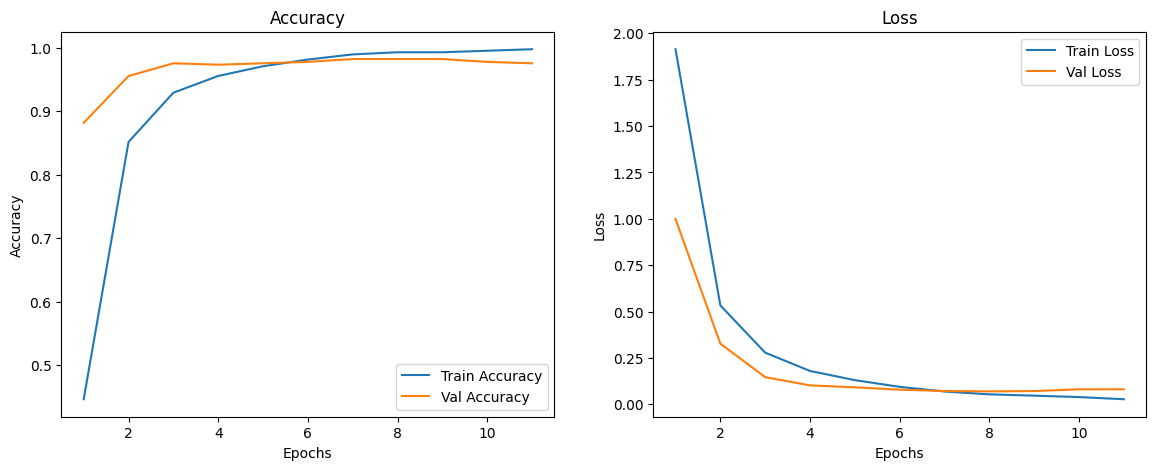

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, title="Training Curves"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Use it like this:
plot_training_history(history)
# plot_training_history(history_finetune, title="Fine-tuning Curves") # Commented out as history_finetune is not defined

##**🧮 Confusion Matrix + Classification Report**

**Objectif :**

Évaluer précisément les performances du modèle.

**Description :**

*  Les prédictions sont générées sur le dataset de test.

*  La matrice de confusion permet d’identifier les erreurs de classification.

*  Le rapport de classification fournit :

    *  Precision

    *  Recall

    *  F1-score par classe

In [ ]:
# Get all predictions
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = best_model_densenet.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels, axis=1))  # if labels are one-hot encoded

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step


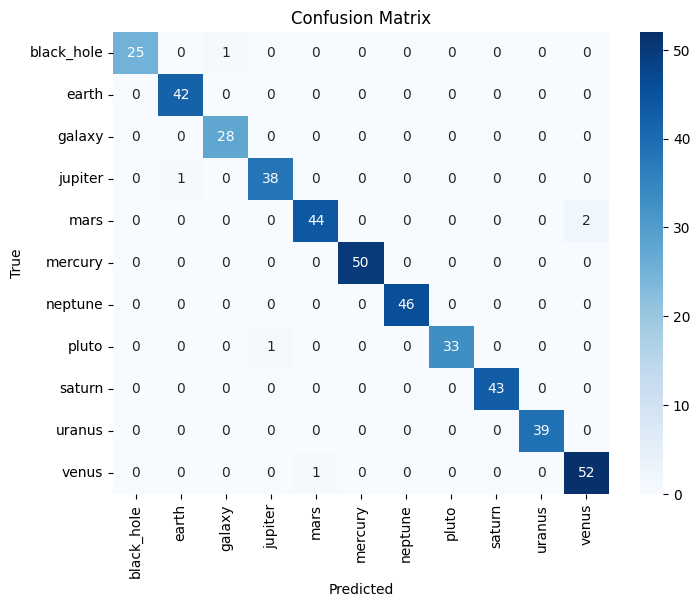


Classification Report:
              precision    recall  f1-score   support

  black_hole       1.00      0.96      0.98        26
       earth       0.98      1.00      0.99        42
      galaxy       0.97      1.00      0.98        28
     jupiter       0.97      0.97      0.97        39
        mars       0.98      0.96      0.97        46
     mercury       1.00      1.00      1.00        50
     neptune       1.00      1.00      1.00        46
       pluto       1.00      0.97      0.99        34
      saturn       1.00      1.00      1.00        43
      uranus       1.00      1.00      1.00        39
       venus       0.96      0.98      0.97        53

    accuracy                           0.99       446
   macro avg       0.99      0.99      0.99       446
weighted avg       0.99      0.99      0.99       446



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

## **🧠 Modèle VGG19 – Fine-tuning** Freezed 5 blocks

**Objectif :**

Comparer les performances avec une architecture plus classique.

**Description :**

*  VGG19 est utilisé comme extracteur de caractéristiques.

*  Seul le bloc convolutionnel 5 est dégelé.

*  Une couche convolutionnelle supplémentaire est ajoutée avant la classification.

*  Un faible learning rate est utilisé pour préserver les poids pré-entraînés.

In [ ]:
from tensorflow.keras.applications.vgg19 import preprocess_input, VGG19
base_vgg= VGG19(include_top=False, weights="imagenet", input_shape=IMG_SIZE+(3,))


for layer in base_vgg.layers:
    layer.trainable = False

unfreeze = False
for layer in base_vgg.layers:
    if layer.name.startswith("block5"):
        unfreeze = True
    layer.trainable = unfreeze

trainable_layers = sum(1 for l in base_vgg.layers if l.trainable)
print(f"Couches entraînables (scénario B): {trainable_layers} / {len(base_vgg.layers)}")

inputs_B = keras.Input(shape=IMG_SIZE+(3,), name="inputs_B")
x_B = data_augmentation(inputs_B)
x_B = preprocess_input(x_B)
x_B = base_vgg(x_B, training=True)

# Couches de features additionnelles
x_B = layers.Conv2D(256, 3, padding="same", use_bias=False)(x_B)
x_B = layers.BatchNormalization()(x_B)
x_B = layers.ReLU()(x_B)

x_B = layers.GlobalAveragePooling2D()(x_B)
x_B = layers.Dropout(0.3)(x_B)
outputs_B = layers.Dense(num_classes, activation="softmax")(x_B)

model_vgg = keras.Model(inputs_B, outputs_B, name="VGG19_FINETUNE_BLOCK5_PLUS")
model_vgg.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Couches entraînables (scénario B): 5 / 22


Model: "VGG19_FINETUNE_BLOCK5_PLUS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs_B            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ inputs_B[0][0]    │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 7, 7, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 256) │  1,179,648 │ vgg19[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 256) │      1,024 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 7, 7, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 11)        │      2,827 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,207,883 (80.90 MB)

 Trainable params: 10,622,219 (40.52 MB)

 Non-trainable params: 10,585,664 (40.38 MB)

In [ ]:
model_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),  # small LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/astro_dataset/Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_model_vgg.keras")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1
    )
]

In [ ]:
EPOCHS = 50

history_vgg5bloc = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.1709 - loss: 2.4806
Epoch 1: val_loss improved from inf to 1.43294, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_model_vgg.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 201ms/step - accuracy: 0.1722 - loss: 2.4768 - val_accuracy: 0.5446 - val_loss: 1.4329 - learning_rate: 5.0000e-06
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5568 - loss: 1.5244
Epoch 2: val_loss improved from 1.43294 to 0.88322, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_model_vgg.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.5577 - loss: 1.5220 - val_accuracy: 0.7545 - val_loss: 0.8832 - learning_rate: 5.0000e-06
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7692 - loss: 0.9621
Epoch 3: val_loss improved from 0.88322 to 0.57872, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_model_vgg.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step 

In [ ]:
from tensorflow import keras
from tensorflow.keras.applications.densenet import preprocess_input
best_model_vgg = keras.models.load_model(
    "/content/drive/MyDrive/astro_dataset/Checkpoints/best_model_vgg.keras",
    custom_objects={'preprocess_input': preprocess_input}
)

In [ ]:
test_loss, test_acc = best_model_vgg.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step - accuracy: 0.9913 - loss: 0.0365
Test Accuracy: 0.9888


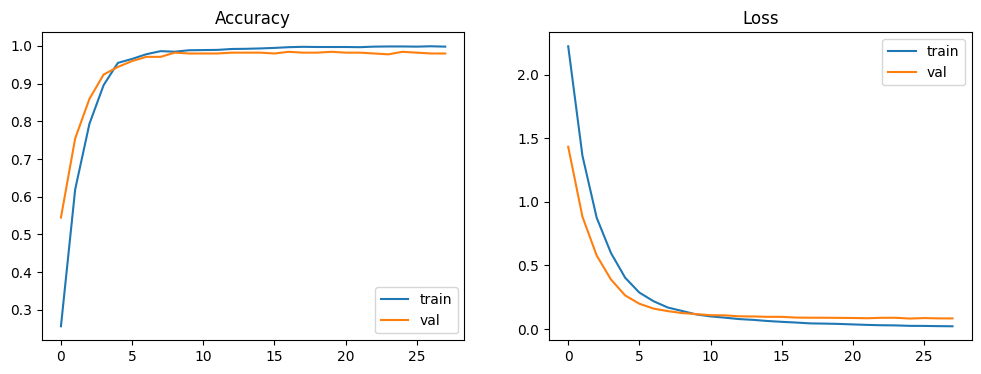

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_vgg5bloc.history['accuracy'], label='train')
plt.plot(history_vgg5bloc.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg5bloc.history['loss'], label='train')
plt.plot(history_vgg5bloc.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
# Get all predictions
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = best_model_vgg.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels, axis=1))  # if labels are one-hot encoded

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


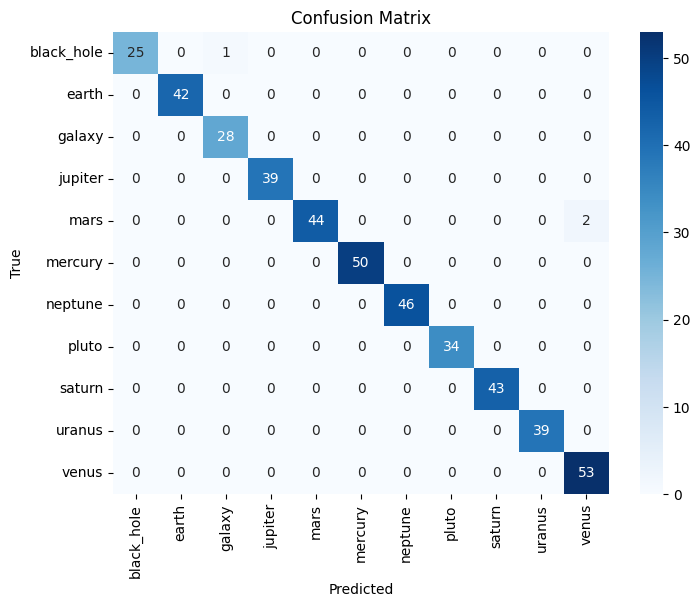


Classification Report:
              precision    recall  f1-score   support

  black_hole       1.00      0.96      0.98        26
       earth       1.00      1.00      1.00        42
      galaxy       0.97      1.00      0.98        28
     jupiter       1.00      1.00      1.00        39
        mars       1.00      0.96      0.98        46
     mercury       1.00      1.00      1.00        50
     neptune       1.00      1.00      1.00        46
       pluto       1.00      1.00      1.00        34
      saturn       1.00      1.00      1.00        43
      uranus       1.00      1.00      1.00        39
       venus       0.96      1.00      0.98        53

    accuracy                           0.99       446
   macro avg       0.99      0.99      0.99       446
weighted avg       0.99      0.99      0.99       446



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

## **🧠 Modèle ResNet50V2 – Fine-tuning** Freezed 40 Layers

**Objectif :**

Tester une architecture résiduelle plus profonde.

**Description :**

*  Les dernières couches résiduelles sont dégelées.

*  Une tête dense est ajoutée avec BatchNorm et Dropout.

*  Entraînement progressif avec reprise possible (initial_epoch).

In [ ]:
# Base model
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers
from tensorflow.keras import Input
from tensorflow.keras import models # Import models here


base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,))

# Unfreeze last 2 residual blocks (~30-40 layers)
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Build model
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs, name="ResNet50V2_FineTune")
model.summary()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),  # small LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50V2_FineTune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,101,387 (91.94 MB)

 Trainable params: 15,766,027 (60.14 MB)

 Non-trainable params: 8,335,360 (31.80 MB)

In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/astro_dataset/Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
checkpoint_path = os.path.join(CHECKPOINT_DIR, "resnet50v2_best_model.keras")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1
    )
]

In [ ]:
EPOCHS = 50

history_80 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.0833 - loss: 3.4202
Epoch 1: val_loss improved from inf to 2.53662, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/resnet50v2_best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 76s 869ms/step - accuracy: 0.0837 - loss: 3.4171 - val_accuracy: 0.1183 - val_loss: 2.5366 - learning_rate: 5.0000e-06
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1905 - loss: 2.7998
Epoch 2: val_loss improved from 2.53662 to 2.13060, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/resnet50v2_best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 64s 985ms/step - accuracy: 0.1912 - loss: 2.7973 - val_accuracy: 0.2634 - val_loss: 2.1306 - learning_rate: 5.0000e-06
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3148 - loss: 2.2463
Epoch 3: val_loss improved from 2.13060 to 1.68054, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/resnet50v2_best_model.keras
66/66 ━━━━━━━━━━━━━━

In [ ]:
from tensorflow import keras
from tensorflow.keras.applications.densenet import preprocess_input
best_model_resnet = keras.models.load_model(
    "/content/drive/MyDrive/astro_dataset/Checkpoints/resnet50v2_best_model.keras",
    custom_objects={'preprocess_input': preprocess_input}
)

In [ ]:
test_loss, test_acc = best_model_resnet.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.8810 - loss: 0.3326
Test Accuracy: 0.8744


In [ ]:
best_model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=callbacks,
    epochs=120,        # final target
    initial_epoch=50   # resume from epoch 50
)

Epoch 51/120
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9889 - loss: 0.0519
Epoch 51: val_loss improved from inf to 0.31814, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/resnet50v2_best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.9889 - loss: 0.0519 - val_accuracy: 0.9152 - val_loss: 0.3181 - learning_rate: 5.0000e-06
Epoch 52/120
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9824 - loss: 0.0630
Epoch 52: val_loss improved from 0.31814 to 0.31390, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/resnet50v2_best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - accuracy: 0.9823 - loss: 0.0630 - val_accuracy: 0.9129 - val_loss: 0.3139 - learning_rate: 5.0000e-06
Epoch 53/120
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9907 - loss: 0.0470
Epoch 53: val_loss did not improve from 0.31390
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9906 - loss: 0.0472 - val_accuracy: 0.9129 - val_loss:

In [ ]:
from tensorflow import keras
from tensorflow.keras.applications.densenet import preprocess_input
best_model_resnet = keras.models.load_model(
    "/content/drive/MyDrive/astro_dataset/Checkpoints/resnet50v2_best_model.keras",
    custom_objects={'preprocess_input': preprocess_input}
)

In [ ]:
test_loss, test_acc = best_model_resnet.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9156 - loss: 0.2588
Test Accuracy: 0.9170


In [ ]:
# Get all predictions
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = best_model_resnet.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels, axis=1))  # if labels are one-hot encoded

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


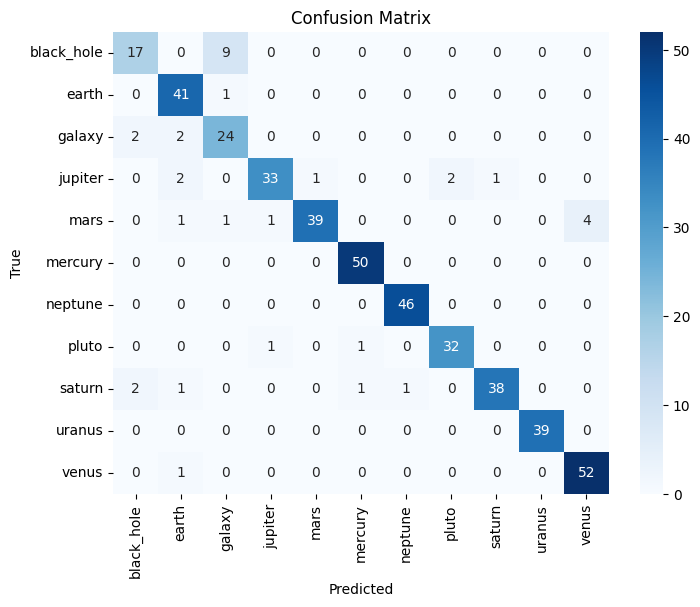


Classification Report:
              precision    recall  f1-score   support

  black_hole       0.81      0.65      0.72        26
       earth       0.85      0.98      0.91        42
      galaxy       0.69      0.86      0.76        28
     jupiter       0.94      0.85      0.89        39
        mars       0.97      0.85      0.91        46
     mercury       0.96      1.00      0.98        50
     neptune       0.98      1.00      0.99        46
       pluto       0.94      0.94      0.94        34
      saturn       0.97      0.88      0.93        43
      uranus       1.00      1.00      1.00        39
       venus       0.93      0.98      0.95        53

    accuracy                           0.92       446
   macro avg       0.91      0.91      0.91       446
weighted avg       0.93      0.92      0.92       446



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

## **🤝 Ensemble Learning (VGG19 + DenseNet)**

**Objectif :**

Améliorer les performances par combinaison de modèles.

**Description :**

*  Les deux meilleurs modèles sont chargés.

*  Leurs prédictions sont combinées par Average Voting.

*  Cette approche réduit la variance et améliore la robustesse.

*  Les métriques évaluées incluent :

    *  Accuracy

    *  F1-score

    *  AUC multiclasses

    *  Cohen’s Kappa

In [ ]:
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Average
from tensorflow import keras
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess_input
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

# Load VGG model
best_model_vgg = keras.models.load_model(
    "/content/drive/MyDrive/astro_dataset/Checkpoints/best_model_vgg.keras",
    custom_objects={'preprocess_input': vgg19_preprocess_input}
)

# Load DenseNet model
best_model_densenet = keras.models.load_model(
    "/content/drive/MyDrive/astro_dataset/Checkpoints/best_densenet.keras",
    custom_objects={'preprocess_input': densenet_preprocess_input} # Corrected
)

# Rename models to avoid graph conflicts
best_model_vgg.name = 'vgg_branch_model'
best_model_densenet.name = 'densenet_branch_model'

# Define new inputs
vgg_input = keras.Input(shape=IMG_SIZE + (3,), name="vgg_ensemble_input")
densenet_input = keras.Input(shape=IMG_SIZE + (3,), name="densenet_ensemble_input")

# Feed new inputs through the loaded models
vgg_output = best_model_vgg(vgg_input)
densenet_output = best_model_densenet(densenet_input)

# Average the outputs (soft voting)
avg_output = Average()([vgg_output, densenet_output])

# Create ensemble model
ensemble_model = Model(inputs=[vgg_input, densenet_input], outputs=avg_output)

# Save
ensemble_model.save("/content/drive/MyDrive/astro_dataset/Checkpoints/ensemble_model.keras")

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.densenet import preprocess_input

ensemble_model = load_model(
    '/content/drive/MyDrive/astro_dataset/Checkpoints/ensemble_model.keras',
     custom_objects={'preprocess_input': preprocess_input}
    )

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# If test_ds is a tf.data.Dataset
x_test = np.concatenate([x for x, y in test_ds], axis=0)
y_test = np.concatenate([y for x, y in test_ds], axis=0)

# Convert one-hot to integer labels if necessary
y_true = np.argmax(y_test, axis=1)
y_probs = ensemble_model.predict([x_test, x_test])
y_pred = np.argmax(y_probs, axis=1)

acc = accuracy_score(y_true, y_pred)
print("Ensemble Accuracy:", acc)

print("Classification Report:\n", classification_report(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

auc = roc_auc_score(y_test, y_probs, multi_class='ovr')
print("Ensemble AUC:", auc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 804ms/step
Ensemble Accuracy: 0.9910313901345291
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       1.00      1.00      1.00        35
           2       0.96      1.00      0.98        25
           3       1.00      1.00      1.00        39
           4       0.98      0.96      0.97        46
           5       1.00      1.00      1.00        50
           6       1.00      1.00      1.00        52
           7       1.00      1.00      1.00        37
           8       1.00      1.00      1.00        41
           9       1.00      1.00      1.00        48
          10       0.96      0.98      0.97        52

    accuracy                           0.99       446
   macro avg       0.99      0.99      0.99       446
weighted avg       0.99      0.99      0.99       446

Confusion Matrix:
 [[20  0  1  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  0  0  0  0  0

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, cohen_kappa_score

# F1 score (macro, micro, weighted)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

# Precision et Recall (macro)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')

# Cohen Kappa
kappa = cohen_kappa_score(y_true, y_pred)

print(f"F1 Macro: {f1_macro:.4f}, F1 Micro: {f1_micro:.4f}, F1 Weighted: {f1_weighted:.4f}")
print(f"Precision Macro: {precision_macro:.4f}, Recall Macro: {recall_macro:.4f}")
print(f"Cohen Kappa: {kappa:.4f}")

F1 Macro: 0.9904, F1 Micro: 0.9910, F1 Weighted: 0.9910
Precision Macro: 0.9911, Recall Macro: 0.9900
Cohen Kappa: 0.9901


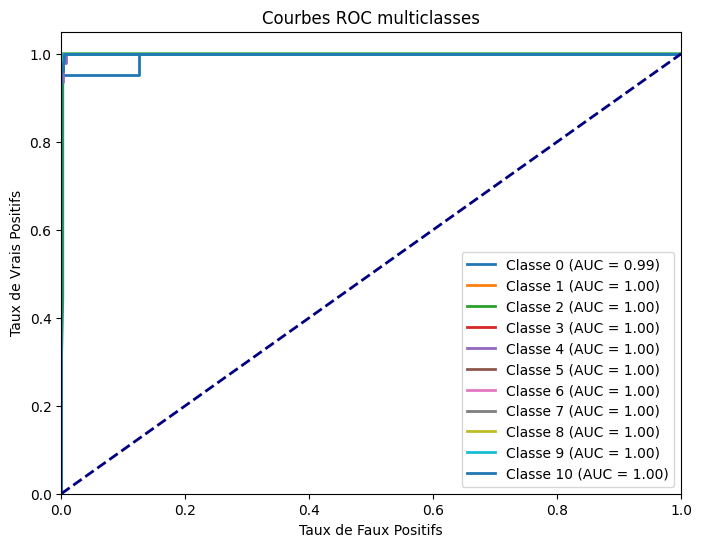

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binariser les labels
n_classes = y_test.shape[1]  # nombre de classes
y_bin = label_binarize(y_true, classes=np.arange(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbes ROC multiclasses')
plt.legend(loc="lower right")
plt.show()

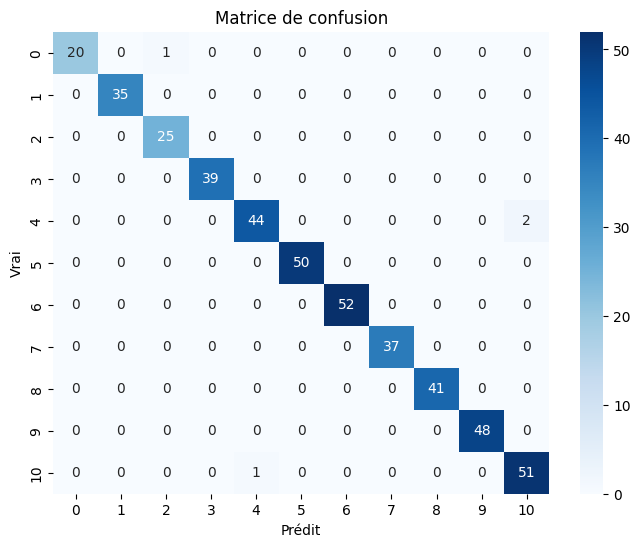

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Vrai")
plt.title("Matrice de confusion")
plt.show()

## **🎯 Prédiction sur une image utilisateur**

**Objectif :**

Tester le modèle en conditions réelles.

**Description :**

*  L’utilisateur téléverse une image.

*  L’image est redimensionnée et prétraitée.

*  Le modèle ensemble prédit la classe et affiche les probabilités.

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess_input
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

print("Please upload an image for prediction.")
uploaded = files.upload()  # This will open a file picker

if not uploaded:
    print("No file uploaded. Please upload an image.")
else:
    img_path = list(uploaded.keys())[0]
    img = Image.open(img_path).convert("RGB")
    img = img.resize(IMG_SIZE)  # Use the global IMG_SIZE

    # Convert to numpy array and add batch dimension
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)  # shape becomes (1, H, W, 3)

    # Preprocess for VGG19 and DenseNet branches
    vgg_processed_img = vgg19_preprocess_input(img_array.copy()) # Use a copy to avoid modifying original
    densenet_processed_img = densenet_preprocess_input(img_array.copy())

    # Make prediction using the ensemble model
    pred_probs = ensemble_model.predict([vgg_processed_img, densenet_processed_img])
    pred_class_idx = np.argmax(pred_probs, axis=1)[0]

    # Use the global class_names
    predicted_class_name = class_names[pred_class_idx]

    print(f"\nPredicted class: {predicted_class_name}")
    print(f"Prediction probabilities: {pred_probs[0]}")

Please upload an image for prediction.


Saving download (1).jpg to download (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Predicted class: saturn
Prediction probabilities: [0.00968  0.004543 0.006275 0.1      0.03108  0.00858  0.0623   0.00491
 0.747    0.01877  0.006897]


## **👁️ Modèle avec Spatial Attention**

**Objectif :**

Améliorer la capacité du réseau à se concentrer sur les zones importantes.

**Description :**

*  Une couche Spatial Attention est intégrée après le backbone ResNet.

*  Elle apprend à pondérer spatialement les cartes de caractéristiques.

*  Le modèle devient plus sensible aux régions discriminantes de l’image.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

class SpatialAttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttentionLayer, self).__init__(**kwargs)
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=7,
            padding='same',
            activation='sigmoid'
        )

    def call(self, input_feature):
        # AveragePool + MaxPool along channel axis
        avg_pool = tf.reduce_mean(input_feature, axis=3, keepdims=True)
        max_pool = tf.reduce_max(input_feature, axis=3, keepdims=True)

        concat = layers.Concatenate(axis=3)([avg_pool, max_pool])

        # 7x7 conv → spatial attention map
        attention = self.conv(concat)

        # Multiply input feature × attention mask
        return layers.Multiply()([input_feature, attention])


# === RESNET BASE MODEL ===
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,)
)

# === UNFREEZE LAST 50 LAYERS ===
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers (ResNet + spatial attention): {trainable_layers} / {len(base_model.layers)}")


# === BUILD MODEL ===
inputs = layers.Input(shape=IMG_SIZE + (3,), name="input_image_with_attention")
x = layers.Lambda(preprocess_input, name="preprocess_attention")(inputs)

x = base_model(x, training=True)

# ---- CBAM Spatial Attention ----
x = SpatialAttentionLayer()(x)

# ---- Custom Classification Head ----
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model_with_attention = Model(inputs, outputs, name="ResNet50_with_SpatialAttention")


# === COMPILE ===
model_with_attention.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

model_with_attention.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable layers (ResNet + spatial attention): 50 / 175


Model: "ResNet50_with_SpatialAttention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image_with_attention      │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_attention (Lambda)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_layer         │ (None, 7, 7, 2048)     │            99 │
│ (SpatialAttentionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,147,694 (92.12 MB)

 Trainable params: 17,509,998 (66.80 MB)

 Non-trainable params: 6,637,696 (25.32 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/astro_dataset/Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# UPDATED NAME
checkpoint_path = os.path.join(CHECKPOINT_DIR, "resnet_cbam.keras")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1
    )
]

# === TRAIN MODEL ===
history = model_with_attention.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,   # early stopping will cut earlier
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.4586 - loss: 2.0023
Epoch 1: val_loss improved from inf to 0.20112, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/resnet_cbam.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 494s 574ms/step - accuracy: 0.4625 - loss: 1.9879 - val_accuracy: 0.9531 - val_loss: 0.2011 - learning_rate: 1.0000e-04
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9738 - loss: 0.1389
Epoch 2: val_loss improved from 0.20112 to 0.09267, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/resnet_cbam.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.9738 - loss: 0.1386 - val_accuracy: 0.9777 - val_loss: 0.0927 - learning_rate: 1.0000e-04
Epoch 3/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9927 - loss: 0.0495
Epoch 3: val_loss improved from 0.09267 to 0.08261, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/resnet_cbam.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy:

In [ ]:
test_loss, test_acc = model_with_attention.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 464ms/step - accuracy: 0.9844 - loss: 0.0592
Test Accuracy: 0.9865, Test Loss: 0.0557


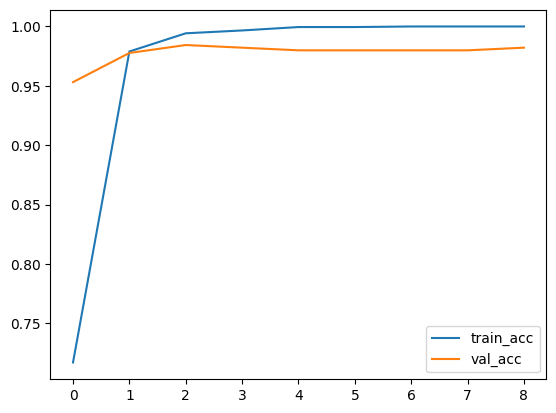

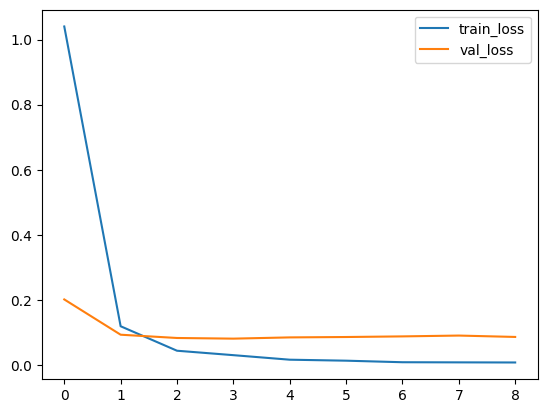

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


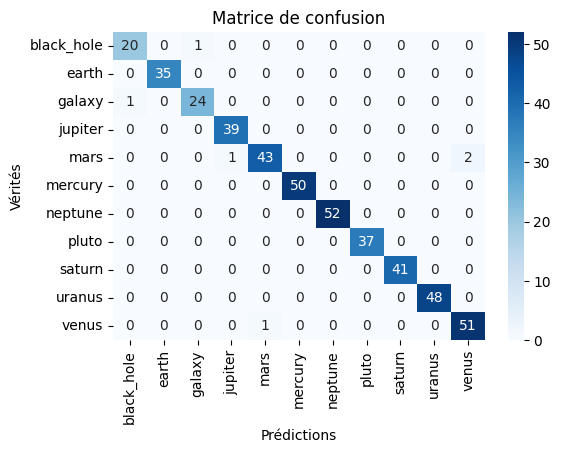

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        21
           1       1.00      1.00      1.00        35
           2       0.96      0.96      0.96        25
           3       0.97      1.00      0.99        39
           4       0.98      0.93      0.96        46
           5       1.00      1.00      1.00        50
           6       1.00      1.00      1.00        52
           7       1.00      1.00      1.00        37
           8       1.00      1.00      1.00        41
           9       1.00      1.00      1.00        48
          10       0.96      0.98      0.97        52

    accuracy                           0.99       446
   macro avg       0.98      0.98      0.98       446
weighted avg       0.99      0.99      0.99       446



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Added import for seaborn
from sklearn.metrics import confusion_matrix, classification_report # Added import statements

# Get all predictions
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model_with_attention.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels, axis=1))  # if labels are one-hot encoded
# 1. Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

# 2. Rapport complet avec support et F1-score
print(classification_report(y_true, y_pred))

## **🧠 ResNet50 + CBAM (Channel + Spatial Attention)**

**Objectif :**

Exploiter pleinement le mécanisme d’attention CBAM.

**Description :**

*  **CBAM combine :**

    *  Channel Attention (quoi regarder)

    *  Spatial Attention (où regarder)

*  Les couches profondes de ResNet sont fine-tunées.

*  Label smoothing est utilisé pour améliorer la généralisation.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
import keras.ops as ops

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input


# ============================================================
#                     CBAM  BLOCK  (UNCHANGED)
# ============================================================
def cbam_block(input_feature, ratio=8, name="cbam"):
    channel = input_feature.shape[-1]

    # ----- Channel Attention -----
    shared_dense_one = layers.Dense(
        channel // ratio,
        activation='relu',
        kernel_initializer='he_normal',
        use_bias=True,
        bias_initializer='zeros'
    )
    shared_dense_two = layers.Dense(
        channel,
        kernel_initializer='he_normal',
        use_bias=True,
        bias_initializer='zeros'
    )

    # Avg Pool
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_one(avg_pool)
    avg_pool = shared_dense_two(avg_pool)

    # Max Pool
    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_dense_one(max_pool)
    max_pool = shared_dense_two(max_pool)

    # Combine + sigmoid
    channel_attention = layers.Add()([avg_pool, max_pool])
    channel_attention = layers.Activation('sigmoid')(channel_attention)

    channel_refined = layers.Multiply()([input_feature, channel_attention])

    # ----- Spatial Attention (keras.ops version) -----
    avg_pool_spatial = ops.mean(channel_refined, axis=-1, keepdims=True)
    max_pool_spatial = ops.max(channel_refined, axis=-1, keepdims=True)

    concat = layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])

    spatial_attention = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding='same',
        activation='sigmoid',
        kernel_initializer='he_normal'
    )(concat)

    refined_feature = layers.Multiply()([channel_refined, spatial_attention])
    return refined_feature

In [ ]:
# ============================================================
#                      RESNET BASE  MODEL
# ============================================================
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,)
)

# Freeze earlier layers (same logic, just using ResNet)
for layer in base_model.layers[:-200]:
    layer.trainable = False
for layer in base_model.layers[-200:]:
    layer.trainable = True

trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"Couches entraînables (scénario B - ResNet): {trainable_layers} / {len(base_model.layers)}")


# ============================================================
#                     BUILD FULL MODEL
# ============================================================
inputs = keras.Input(shape=IMG_SIZE + (3,), name="input_image")

x = data_augmentation(inputs)

# ResNet preprocessing
x = layers.Lambda(preprocess_input, name="preprocess")(inputs)

x = base_model(x, training=True)

# ⭐ ADD CBAM before GAP (exactly like DenseNet version)
x = cbam_block(x, ratio=8)

# ------------------------------------------------------------
#                Classification head (unchanged)
# ------------------------------------------------------------
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="ResNet50_FineTuned_CBAM")


# ============================================================
#                         COMPILE
# ============================================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

Couches entraînables (scénario B - ResNet): 175 / 175


Model: "ResNet50_FineTuned_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocess (Lambda) │ (None, 224, 224,  │          0 │ input_image[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ preprocess[0][0]  │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ global_max_pooli… │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1, 1, 256) │    524,544 │ reshape[0][0],    │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1, 1,      │    526,336 │ dense_9[0][0],    │
│                     │ 2048)             │            │ dense_9[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 1,      │          0 │ dense_10[0][0],   │
│                     │ 2048)             │            │ dense_10[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1, 1,      │          0 │ add_1[0][0]       │
│ (Activation)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 7, 7,      │          0 │ resnet50[0][0],   │
│ (Multiply)          │ 2048)             │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Mean)         │ (None, 7, 7, 1)   │          0 │ multiply_7[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max (Max)           │ (None, 7, 7, 1)   │          0 │ multiply_7[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 7, 7, 2)   │          0 │ mean[0][0],       │
│ (Concatenate)       │                   │            │ max[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 1)   │         99 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_8          │ (None, 7, 7,      │          0 │ multiply_7[0][0], │
│ (Multiply)          │ 2048)             │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ multiply_8[0][0]

 Total params: 25,853,422 (98.62 MB)

 Trainable params: 25,800,302 (98.42 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/astro_dataset/Checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# UPDATED CHECKPOINT NAME
checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_resnet_cbam1.keras")

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,   # early stopping will stop earlier
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.1162 - loss: 2.4260
Epoch 1: val_loss improved from inf to 2.37988, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_resnet_cbam1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.1163 - loss: 2.4257 - val_accuracy: 0.1562 - val_loss: 2.3799 - learning_rate: 5.0000e-06
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.1663 - loss: 2.3428
Epoch 2: val_loss improved from 2.37988 to 2.30319, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_resnet_cbam1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - accuracy: 0.1665 - loss: 2.3425 - val_accuracy: 0.3192 - val_loss: 2.3032 - learning_rate: 5.0000e-06
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.2207 - loss: 2.2576
Epoch 3: val_loss improved from 2.30319 to 2.17300, saving model to /content/drive/MyDrive/astro_dataset/Checkpoints/best_resnet_cbam1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 18

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.9875 - loss: 0.6060
Test Accuracy: 0.9843


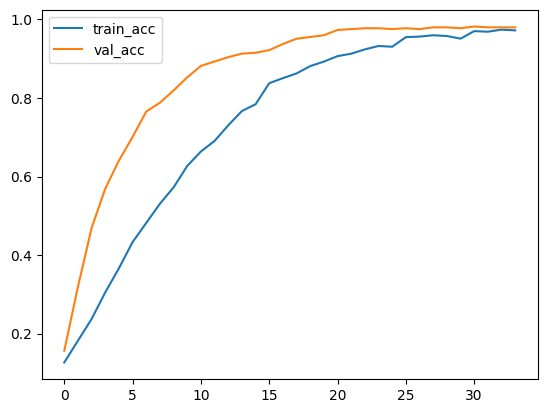

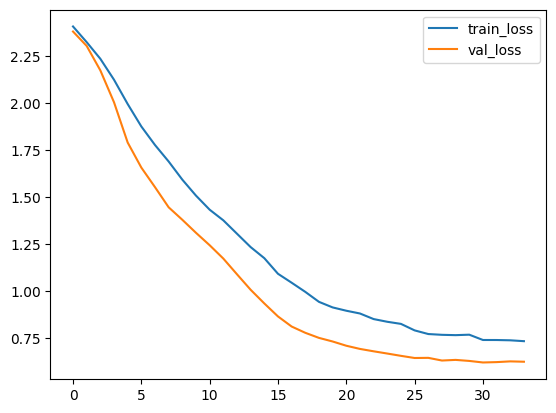

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [ ]:
# Get all predictions
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels, axis=1))  # if labels are one-hot encoded

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


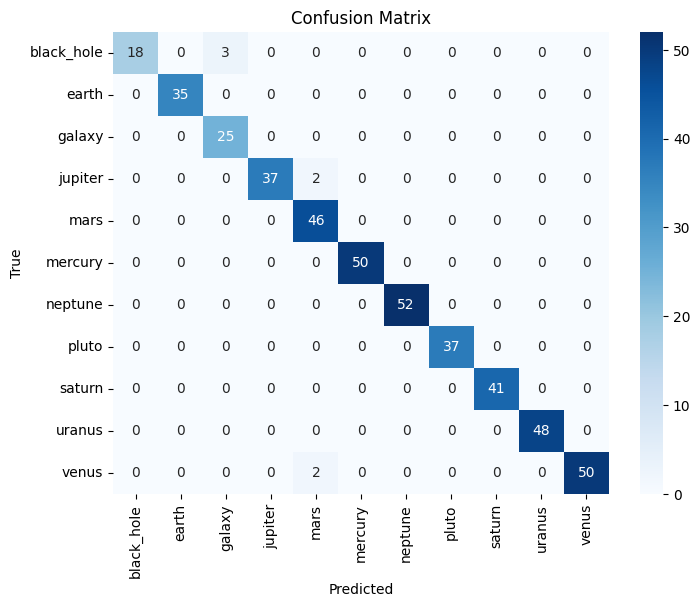


Classification Report:
              precision    recall  f1-score   support

  black_hole       1.00      0.86      0.92        21
       earth       1.00      1.00      1.00        35
      galaxy       0.89      1.00      0.94        25
     jupiter       1.00      0.95      0.97        39
        mars       0.92      1.00      0.96        46
     mercury       1.00      1.00      1.00        50
     neptune       1.00      1.00      1.00        52
       pluto       1.00      1.00      1.00        37
      saturn       1.00      1.00      1.00        41
      uranus       1.00      1.00      1.00        48
       venus       1.00      0.96      0.98        52

    accuracy                           0.98       446
   macro avg       0.98      0.98      0.98       446
weighted avg       0.99      0.98      0.98       446



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

##**✅ Conclusion**

Ce projet explore différentes stratégies avancées de deep learning :
transfer learning, fine-tuning, attention mechanisms et ensemble learning, afin d’obtenir des performances robustes et généralisables sur un dataset d’images.